# Presentation

In [1]:
pip install nanonispy2

In [2]:
%cd /content/drive/MyDrive/

/content/drive/MyDrive


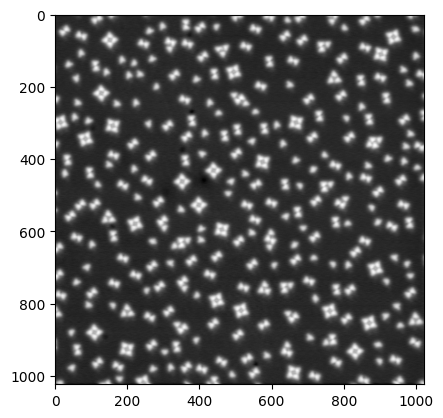

In [3]:
import nanonispy2 as nap
import matplotlib.pyplot as plt
import nanonispyfit
import numpy as np
sxm = nap.read.Scan('/content/drive/MyDrive/sxm/Helicene_Ag(111)008.sxm')
im = sxm.signals["Z"]["backward"] # Full out the image in the 'forward' direction
flattened = nanonispyfit.plane_fit_2d(im)
flipped = np.rot90(flattened, 2)
plt.imshow(flipped, cmap = 'gray')

Detected 272 molecules


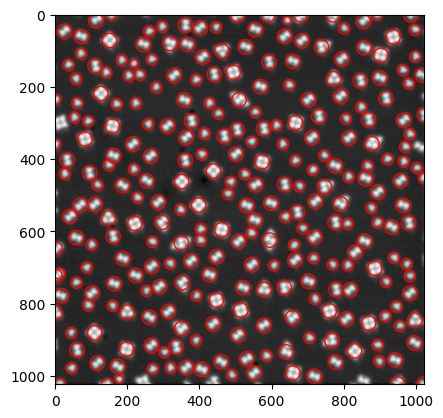

In [26]:
import numpy as np
from skimage.feature import blob_log
# Normalize
img = (flipped - flipped.min()) / (flipped.max() - flipped.min())

# Blob detection (molecules appear as bright blobs)
blobs = blob_log(img, max_sigma=10, num_sigma=5, threshold=0.3)

print(f"Detected {len(blobs)} molecules")

# Plot
fig, ax = plt.subplots()
ax.imshow(img, cmap="gray")
for y, x, r in blobs:
    c = plt.Circle((x, y), r*2, color="red", fill=False, linewidth=1)
    ax.add_patch(c)
plt.show()

In [5]:
patch_size = 36  # can be 36/40/44/48/52/56 depending on molecule size

# 1. Pad the image so edge blobs get full patches
pad = patch_size // 2
padded = np.pad(img, pad, mode="reflect")

# 2. Extract patches
patches = []
valid_blobs = []
for y, x, r in blobs:
    y, x = int(y), int(x)
    patch = padded[y:y+patch_size, x:x+patch_size]  # always full-size
    patches.append(patch)
    valid_blobs.append((y, x, r))

# 3. Convert to array
patches = np.array(patches)[..., np.newaxis]  # shape: (N, patch_size, patch_size, 1)
valid_blobs = np.array(valid_blobs)

print("Patches shape:", patches.shape)
print("Number of blobs kept:", len(valid_blobs))


Patches shape: (272, 36, 36, 1)
Number of blobs kept: 272


In [6]:
patches = patches.astype("float32")
patches /= patches.max()  # normalise

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

input_shape = (patch_size, patch_size, 1)

# Encoder
inp = layers.Input(shape=input_shape)
x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
x = layers.MaxPooling2D(2)(x)
encoded = layers.Flatten()(x)
encoded = layers.Dense(32, activation="relu")(encoded)  # embedding

# Decoder
x = layers.Dense((patch_size//4) * (patch_size//4) * 64, activation="relu")(encoded)
x = layers.Reshape((patch_size//4, patch_size//4, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, activation="relu", padding="same")(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation="relu", padding="same")(x)
decoded = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)

autoencoder = models.Model(inp, decoded)
autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 36, 36, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 36, 36, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 18, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 18, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       165,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5184)           │       171,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 18, 18, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 36, 36, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 36, 36, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 411,489 (1.57 MB)

 Trainable params: 411,489 (1.57 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create the generator with rotation
datagen = ImageDataGenerator(rotation_range=360)

# Train the autoencoder using the generator
autoencoder.fit(
    datagen.flow(patches, patches, batch_size=32),
    epochs=20,
)



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 122ms/step - loss: 0.0553
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.0483
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.0337
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - loss: 0.0263
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step - loss: 0.0252
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 202ms/step - loss: 0.0219
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step - loss: 0.0203
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0125
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - loss: 0.0113
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - loss: 0.0105
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - loss: 0.0103
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 120ms/step - loss: 0.0097
Epoch 13/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - loss: 0.0096
Epoch 14/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0097
Epoch 15/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - loss: 0.0090
Epoch 16/50
9/9 ━━━

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

encoder = models.Model(inp, encoded)
features = encoder.predict(patches)

scores = {}
for k in range(3, 11):
    kmeans = KMeans(n_clusters=k, random_state=42).fit(features)
    labels = kmeans.labels_
    score = silhouette_score(features, labels)
    scores[k] = score
    print(f"k={k}, silhouette={score:.3f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
k=3, silhouette=0.796
k=4, silhouette=0.843
k=5, silhouette=0.822
k=6, silhouette=0.756
k=7, silhouette=0.688
k=8, silhouette=0.671
k=9, silhouette=0.630
k=10, silhouette=0.626


In [41]:
# Cluster molecules
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=6, random_state=42).fit(features)
labels = kmeans.labels_


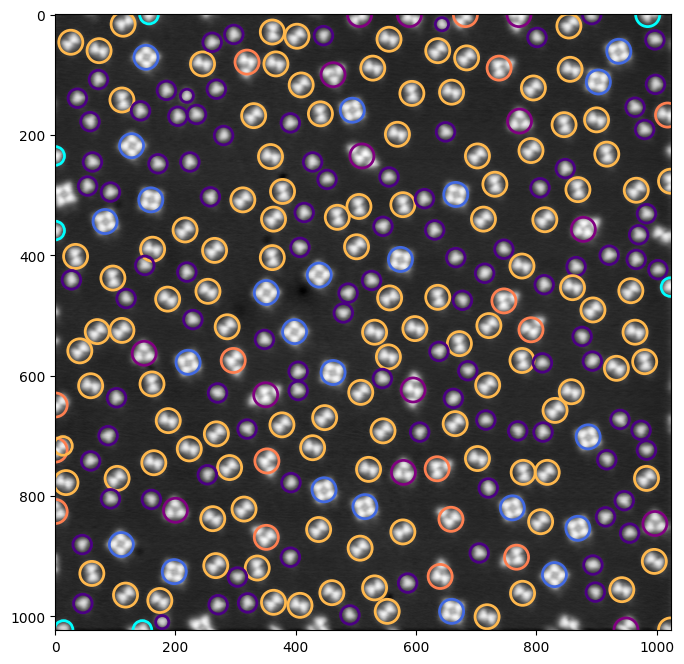

In [44]:
import matplotlib.pyplot as plt

# Define your own color mapping for each cluster
# Example: cluster 0 = red, 1 = blue, 2 = green, etc.
cluster_colors = {
    0: "#FF7F50",
    1: "#4B0082",
    2: "#FFB84D",
    3: "#4169E1",
    4: "purple",
    5: "cyan",
    6: "purple",
    7: "blue",
    8: "brown",
    9: "pink"
}

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(img, cmap="gray")

for (y, x, r), label in zip(valid_blobs, labels):
    color = cluster_colors.get(label, "black")  # default to black if label not in dict
    c = plt.Circle((x, y), r*2, color=color, fill=False, linewidth=2)
    ax.add_patch(c)

plt.show()


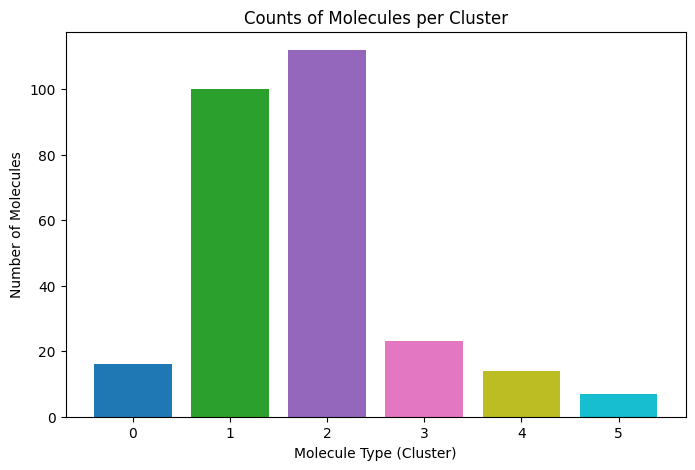

In [46]:
unique, counts = np.unique(labels, return_counts=True)

# Plot bar chart
plt.figure(figsize=(8,5))
plt.bar(unique, counts, color=plt.cm.tab10(unique / unique.max()))
plt.xlabel("Molecule Type (Cluster)")
plt.ylabel("Number of Molecules")
plt.title("Counts of Molecules per Cluster")
plt.xticks(unique)  # label clusters as 0,1,2...
plt.show()

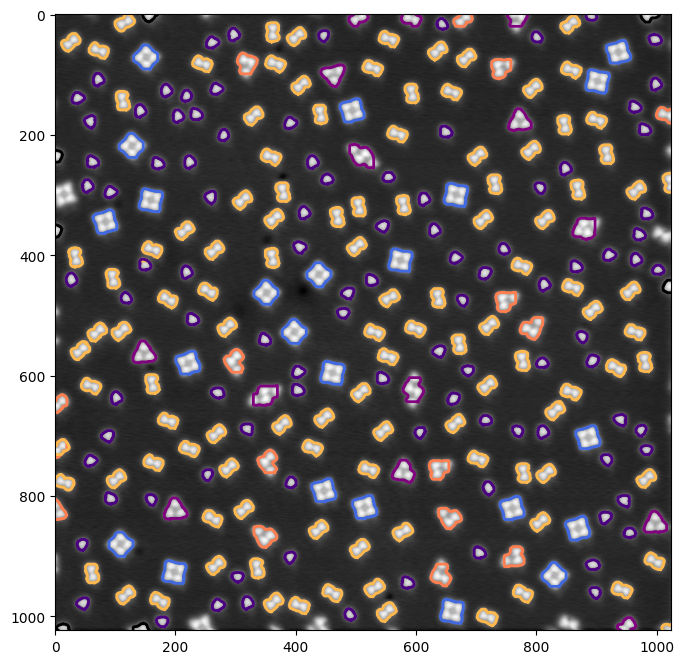

In [48]:
import matplotlib.pyplot as plt
from skimage import measure
import numpy as np

# Define your custom colors
cluster_colors = {
    0: "#FF7F50",
    1: "#4B0082",
    2: "#FFB84D",
    3: "#4169E1",
    4: "purple",
    5: "black",
    6: "purple",
    7: "blue",
    8: "brown",
    9: "pink"
}

# Create figure
fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(img, cmap="gray")

# Create a binary mask for molecules
threshold = img.mean() + 0.3*(img.max() - img.mean())
binary = img > threshold

# Label connected regions (each molecule)
labeled_regions = measure.label(binary)

# Loop through each molecule and plot its contour
for i, ((y, x, r), cluster_label) in enumerate(zip(valid_blobs, labels)):
    y, x = int(y), int(x)
    radius = int(r*2)
    mask = np.zeros_like(binary, dtype=bool)
    y_min, y_max = max(0, y-radius), min(binary.shape[0], y+radius)
    x_min, x_max = max(0, x-radius), min(binary.shape[1], x+radius)
    mask[y_min:y_max, x_min:x_max] = binary[y_min:y_max, x_min:x_max]

    # Find contours for this molecule
    contours = measure.find_contours(mask, 0.5)
    color = cluster_colors.get(cluster_label, "black")  # fallback to black

    for contour in contours:
        ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color=color)

plt.show()


